In [28]:
from idlelib.autocomplete import TRY_F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.ma.extras import unique

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, \
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance

import os, errno
from pathlib import Path
import json

In [29]:
RANDOM_STATE=1

In [30]:
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)

In [31]:
def get_metrics(predict, target, predict_proba=None):
    m = {
        'accuracy': accuracy_score(target, predict),
        'precision': precision_score(target, predict, zero_division=1.0),
        'recall': recall_score(target, predict, zero_division=1.0),
        'f1': f1_score(target, predict),
        'matrix': confusion_matrix(target, predict),
        'roc_auc': None,
    }
    if predict_proba is not None:
        m['roc_auc'] = roc_auc_score(target, predict)

    return m

def evaluate_metrics(model, X, Y, label: str):
    pred = model.predict(X)
    proba = None
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)[:, 1]

    metrics = get_metrics(pred, Y, proba)
    metrics['label'] = label

    show_confusion_matrix(metrics['matrix'], f'artifacts/figures/{label}_metrics/confusion_matrix.png', name=label)
    show_pr_curve(model, X, Y, f'artifacts/figures/{label}_metrics/pr_curve.png', name=label)
    if proba is not None:
        show_roc_curve(model, X, Y, f'artifacts/figures/{label}_metrics/roc_curve.png', name=label)

    return metrics


def show_confusion_matrix(confusion_matrix, path, name=None):
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=None)
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Confusion Matrix {name}")

    create_or_check_dir(path)

    plt.savefig(path)
    plt.show()

def show_roc_curve(model, data, target, path, name=None):
    RocCurveDisplay.from_estimator(model, data, target)
    plt.title(f"ROC Curve {name}")

    create_or_check_dir(path)
    plt.savefig(path)

def show_pr_curve(model, data, target, path, name=None):
    PrecisionRecallDisplay.from_estimator(model, data, target)

    plt.title(f"Precision-Recall Curve {name}")
    create_or_check_dir(path)
    plt.savefig(path)


def create_or_check_dir(path: str):
    if not os.path.exists(os.path.dirname(path)):
        try:
            os.makedirs(os.path.dirname(path))
        except OSError as exc:
            if exc.errno != errno.EEXIST:
                raise


In [32]:
df = pd.read_csv("./datasets/S06-hw-dataset-04.csv")

In [33]:
df.shape

(25000, 62)

In [34]:
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 62 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      25000 non-null  int64  
 1   f01     25000 non-null  float64
 2   f02     25000 non-null  float64
 3   f03     25000 non-null  float64
 4   f04     25000 non-null  float64
 5   f05     25000 non-null  float64
 6   f06     25000 non-null  float64
 7   f07     25000 non-null  float64
 8   f08     25000 non-null  float64
 9   f09     25000 non-null  float64
 10  f10     25000 non-null  float64
 11  f11     25000 non-null  float64
 12  f12     25000 non-null  float64
 13  f13     25000 non-null  float64
 14  f14     25000 non-null  float64
 15  f15     25000 non-null  float64
 16  f16     25000 non-null  float64
 17  f17     25000 non-null  float64
 18  f18     25000 non-null  float64
 19  f19     25000 non-null  float64
 20  f20     25000 non-null  float64
 21  f21     25000 non-null  float64
 22

In [36]:
df.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,12500.500000,-0.000386,-0.004872,0.003202,0.335329,-0.000563,-0.010118,0.001182,0.957385,-0.004658,...,-0.166251,-3.387506,1.749793,-0.013017,-0.001383,0.893365,-0.909479,0.000570,-0.000754,0.04920
std,7217.022701,1.001623,0.995606,1.004367,3.207537,0.993965,1.002172,2.432162,1.830223,1.013470,...,4.234741,4.331576,5.318660,1.001594,0.996409,2.445185,1.962618,0.994320,0.997167,0.21629
min,1.000000,-4.370993,-4.087073,-4.103875,-13.249937,-4.118778,-3.895974,-8.883224,-8.132548,-4.068933,...,-20.021141,-18.332290,-20.336666,-4.349216,-4.119472,-9.508509,-7.919287,-4.038312,-3.812255,0.00000
25%,6250.750000,-0.680165,-0.675100,-0.675426,-1.750048,-0.669764,-0.674374,-1.647977,-0.217260,-0.688278,...,-2.897904,-6.278403,-1.775889,-0.689962,-0.676191,-0.735473,-2.226959,-0.666367,-0.665861,0.00000
50%,12500.500000,0.001859,-0.000247,0.013272,0.403483,-0.001309,-0.005994,-0.011349,0.963009,0.000414,...,-0.396946,-3.462072,1.931851,-0.020933,-0.004193,0.888535,-0.923354,0.004381,0.002420,0.00000
75%,18750.250000,0.679702,0.659523,0.683437,2.486453,0.672299,0.652629,1.658680,2.167758,0.681040,...,2.344956,-0.578540,5.473886,0.661300,0.673722,2.516790,0.395648,0.666474,0.665918,0.00000
max,25000.000000,4.208888,3.984564,3.793442,15.288250,4.020733,4.279607,9.538525,9.321099,4.261349,...,20.717964,18.818764,20.688069,4.338337,3.902131,11.880651,6.778980,3.834922,4.012639,1.00000


In [37]:
df.target.value_counts()

target
0    23770
1     1230
Name: count, dtype: int64

In [38]:
X = df.drop('target', axis=1)
Y = df['target']

In [39]:
# Фиксированный RANDOM_STATE нужен для того, что бы при разном запуске кода модели и тд давали 1 и тот же результат
# stratify=Y нужен для сохранения дисбаланса target классов в train\test выборках, так как классы имеют большой дисбаланс
train_data, test_data, train_target, test_target = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE, stratify=Y)

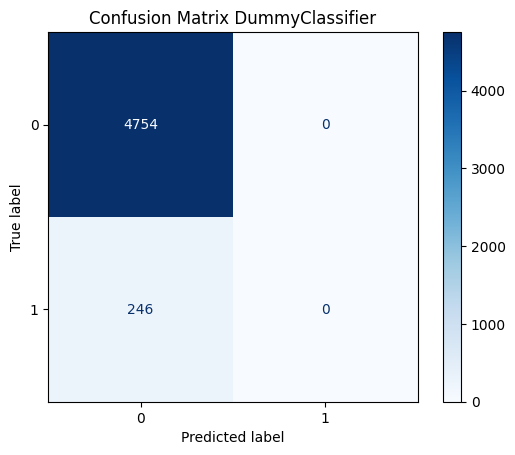

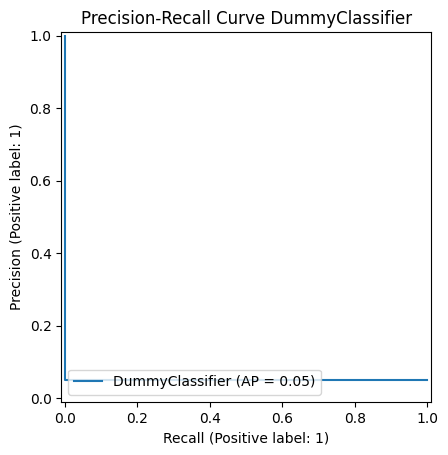

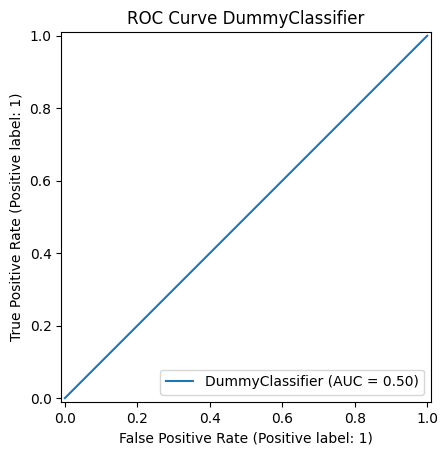

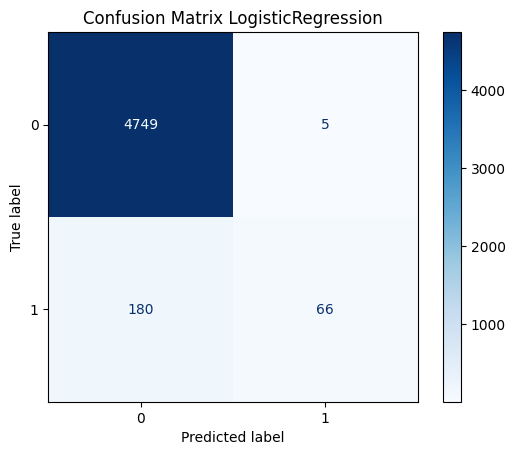

{'best_params': {'lr__C': 0.1, 'lr__solver': 'lbfgs'},
 'roc_auc': np.float64(0.8214950220697309)}

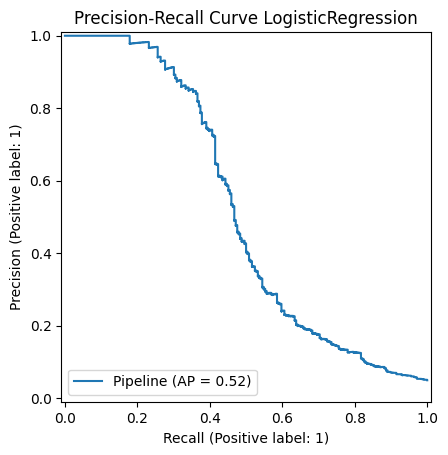

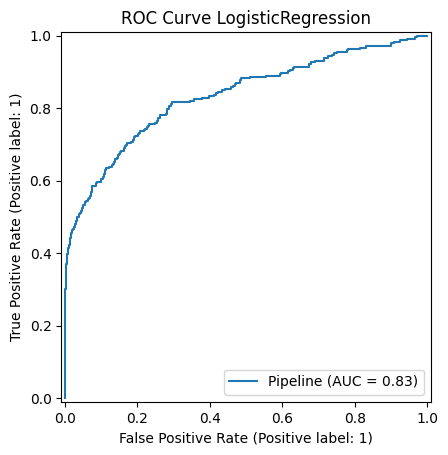

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
best_models = {}
search_summaries = {}

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(train_data, train_target)
results.append(evaluate_metrics(dummy, test_data, test_target, "DummyClassifier"))
best_models['DummyClassifier'] = dummy
search_summaries['DummyClassifier'] = {}

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=200, random_state=RANDOM_STATE)),
])

lr_grid = {
    "lr__C": [0.1, 1, 10, 100],
    "lr__solver": ["lbfgs"],
}

lr_search = GridSearchCV(
    lr,
    lr_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)
lr_search.fit(train_data, train_target)
best_lr = lr_search.best_estimator_
best_models['LogisticRegression'] = best_lr

search_summaries['LogisticRegression'] = {
    "best_params": lr_search.best_params_,
    "roc_auc": lr_search.best_score_,
}

results.append(evaluate_metrics(best_lr, test_data, test_target, "LogisticRegression"))
best_models['LogisticRegression'] = best_lr

search_summaries['LogisticRegression']

In [41]:
def run_search(model, label, param_grid):
    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )

    search.fit(train_data, train_target)

    best = search.best_estimator_
    best_models[label] = best
    results.append(evaluate_metrics(best, test_data, test_target, label))
    search_summaries[label] = {
        "best_params": search.best_params_,
        "roc_auc": search.best_score_,
    }

    return search

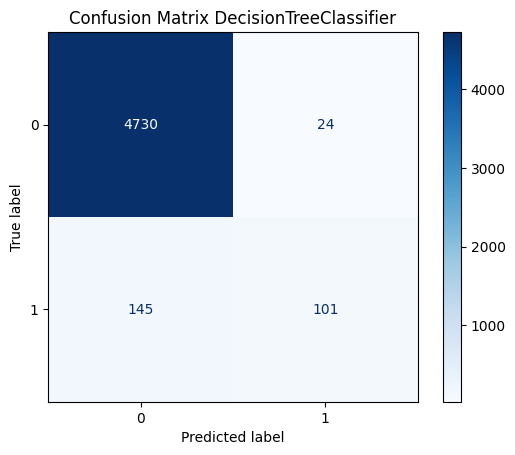

{'best_params': {'ccp_alpha': 0, 'max_depth': 7, 'min_samples_leaf': 20},
 'roc_auc': np.float64(0.7751010846088564)}

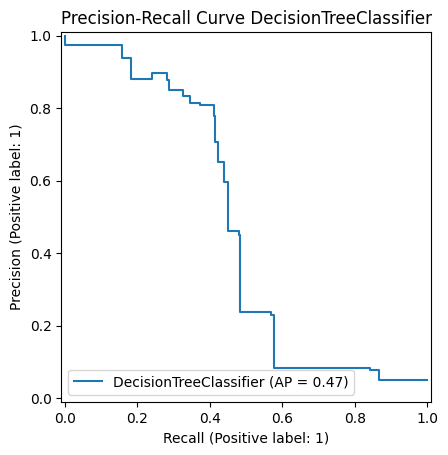

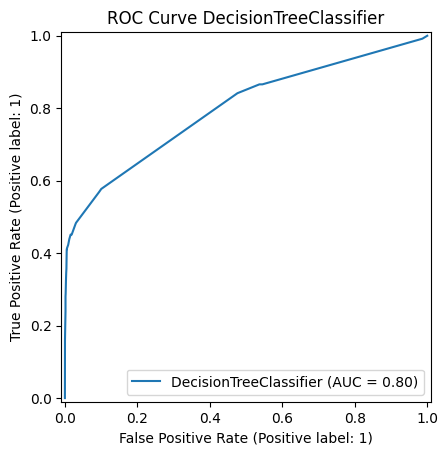

In [42]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_grid = {
    "max_depth": [1, 3, 5, 7],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0, 0.001, 0.005, 0.01]
}

dt_search = run_search(dt, "DecisionTreeClassifier", dt_grid)
search_summaries["DecisionTreeClassifier"]

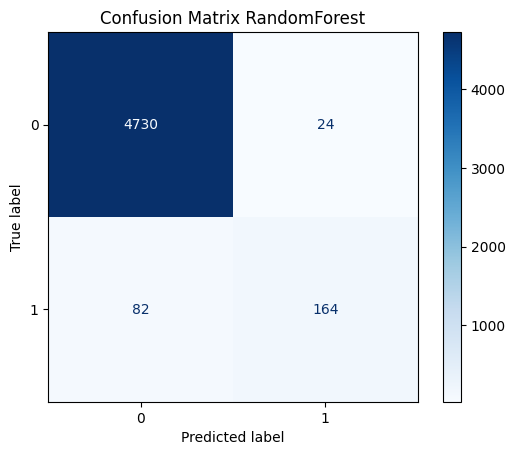

{'best_params': {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 10},
 'roc_auc': np.float64(0.8964805503177719)}

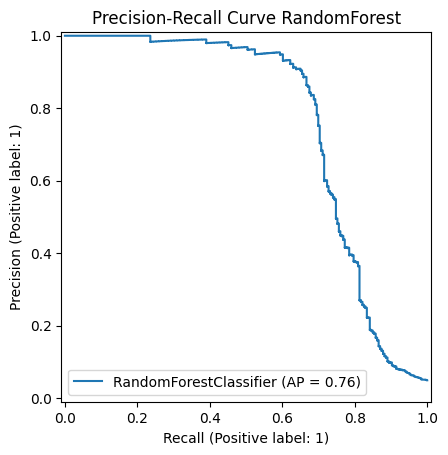

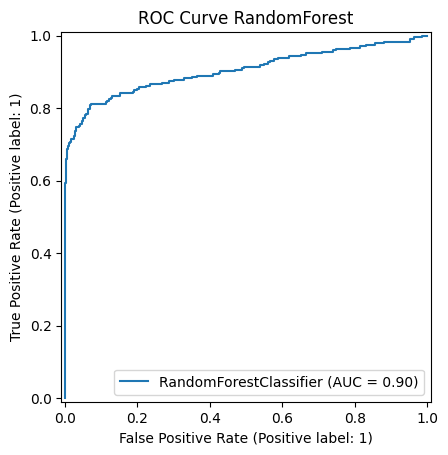

In [43]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=6,
    class_weight='balanced',
    oob_score=False
)

rf_grid = {
    "max_depth": [6, 10],
    "min_samples_leaf": [5, 10],
    "max_features": ["sqrt", 0.5],
}

rf_search = run_search(rf, "RandomForest", rf_grid)
search_summaries["RandomForest"]

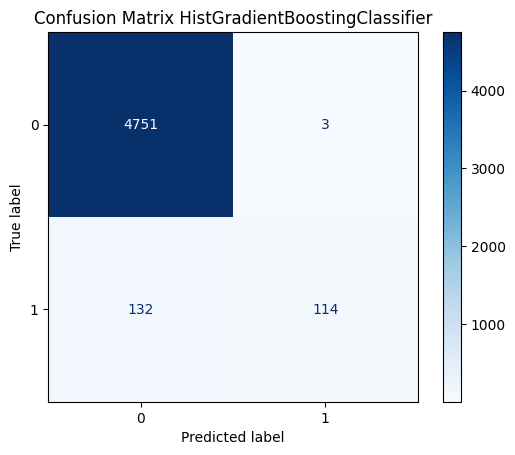

{'best_params': {'learning_rate': 0.05, 'max_depth': 3, 'max_leaf_nodes': 15},
 'roc_auc': np.float64(0.8880418171801047)}

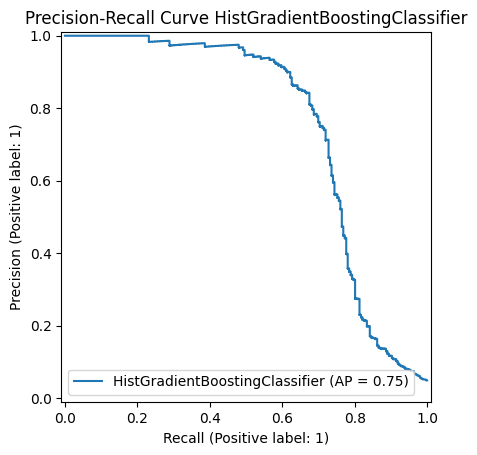

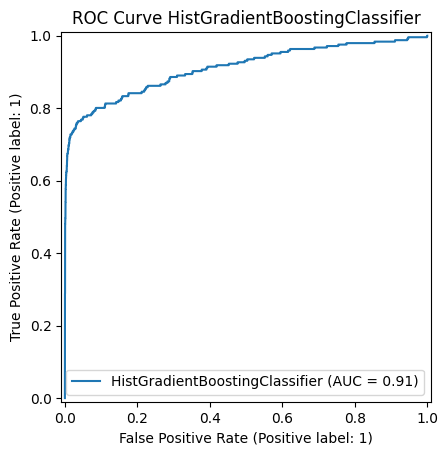

In [44]:
hgb = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True,
)

hgb_grid = {
    "learning_rate": [0.1, 0.05, 1, 0.5],
    "max_depth": [1, 2, 3],
    "max_leaf_nodes": [15, 31, 63],
}
hgb_search = run_search(hgb, "HistGradientBoostingClassifier", hgb_grid)
search_summaries["HistGradientBoostingClassifier"]

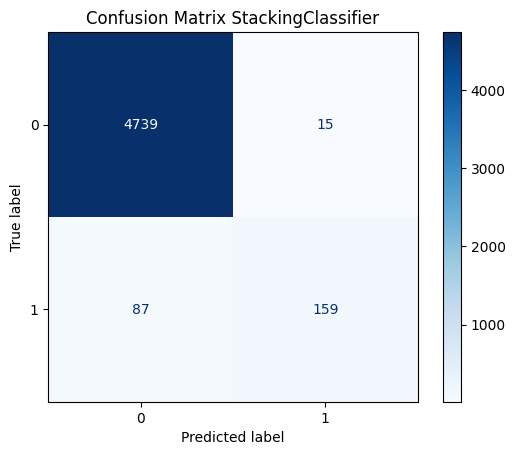

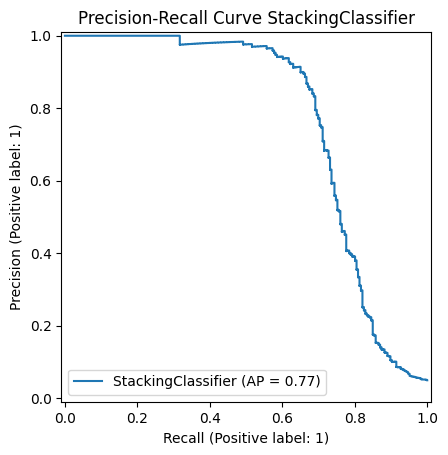

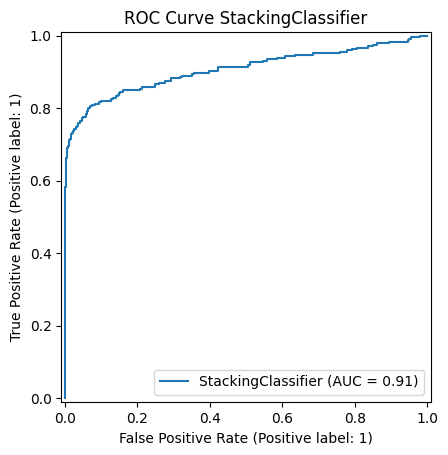

In [45]:

estimator = list()
estimator.append(("lr", best_models['LogisticRegression']))
estimator.append(("rf", best_models['RandomForest']))
estimator.append(("hgb", best_models['HistGradientBoostingClassifier']))

stack = StackingClassifier(
    estimators=estimator,
    final_estimator=LogisticRegression(max_iter=6000, random_state=RANDOM_STATE),
    n_jobs=5,
    cv=cv,
    passthrough=False,
)

stack.fit(train_data, train_target)
best_models['StackingClassifier'] = stack
results.append(evaluate_metrics(stack, test_data, test_target, "StackingClassifier"))
search_summaries['StackingClassifier'] = {}

In [46]:
df = pd.DataFrame(results)

df_sorted = df.copy()
df_sorted['roc_auc_sort'] = df_sorted['roc_auc'].fillna(-1.0)
df_sorted = df_sorted.sort_values(['roc_auc_sort', 'accuracy'], ascending=False).drop(columns=['roc_auc_sort'])

"""3,0.9776,0.864130,0.646341,0.739535,"[[4729, 25], [87, 159]]",0.820541,RandomForest
5,0.9786,0.892655,0.642276,0.747045,"[[4735, 19], [88, 158]]",0.819140,StackingClassifier
4,0.9760,0.950000,0.540650,0.689119,"[[4747, 7], [113, 133]]",0.769589,HistGradientBoostingClassifier
2,0.9648,0.796610,0.382114,0.516484,"[[4730, 24], [152, 94]]",0.688533,DecisionTreeClassifier
1,0.9632,0.907895,0.280488,0.428571,"[[4747, 7], [177, 69]]",0.639508,LogisticRegression
0,0.9508,1.000000,0.000000,0.000000,"[[4754, 0], [246, 0]]",0.500000,DummyClassifier
"""

'''
3,0.9768,0.838542,0.654472,0.735160,"[[4723, 31], [85, 161]]",0.823975,RandomForest
5,0.9778,0.894737,0.621951,0.733813,"[[4736, 18], [93, 153]]",0.809082,StackingClassifier
4,0.9732,0.974576,0.467480,0.631868,"[[4751, 3], [131, 115]]",0.733424,HistGradientBoostingClassifier
2,0.9660,0.816667,0.398374,0.535519,"[[4732, 22], [148, 98]]",0.696873,DecisionTreeClassifier
1,0.9620,0.900000,0.256098,0.398734,"[[4747, 7], [183, 63]]",0.627313,LogisticRegression
0,0.9508,1.000000,0.000000,0.000000,"[[4754, 0], [246, 0]]",0.500000,DummyClassifier
'''

df_sorted

,accuracy,precision,recall,f1,matrix,roc_auc,label
3,0.9788,0.872340,0.666667,0.755760,"[[4730, 24], [82, 164]]",0.830809,RandomForest
5,0.9796,0.913793,0.646341,0.757143,"[[4739, 15], [87, 159]]",0.821593,StackingClassifier
4,0.9730,0.974359,0.463415,0.628099,"[[4751, 3], [132, 114]]",0.731392,HistGradientBoostingClassifier
2,0.9662,0.808000,0.410569,0.544474,"[[4730, 24], [145, 101]]",0.702760,DecisionTreeClassifier
1,0.9630,0.929577,0.268293,0.416404,"[[4749, 5], [180, 66]]",0.633620,LogisticRegression
0,0.9508,1.000000,0.000000,0.000000,"[[4754, 0], [246, 0]]",0.500000,DummyClassifier


In [47]:
def json_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    raise TypeError(f"{type(o)} is not JSON serializable")


def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(
            obj,
            f,
            ensure_ascii=False,
            indent=2,
            default=json_default
        )

metrics_path = ARTIFACTS_DIR / 'metrics_test.json'
search_path = ARTIFACTS_DIR / 'search_summaries.json'
best_models_path = ARTIFACTS_DIR / 'best_model_meta.json'

save_json({"results": df_sorted.to_dict(orient="records")}, metrics_path)
save_json(search_summaries, search_path)

print(f'''
    Save metrics json for path {metrics_path.name}
    Save search json for path {search_path.name}
''')


    Save metrics json for path metrics_test.json
    Save search json for path search_summaries.json



In [48]:
best_row = df_sorted.iloc[0]
best_model = best_models[best_row['label']]
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

In [49]:
def sanitize_obj(o):
    import numpy as np
    if isinstance(o, (int, float, str, bool)) or o is None:
        return o
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    if isinstance(o, list):
        return [sanitize_obj(x) for x in o]
    if isinstance(o, dict):
        return {k: sanitize_obj(v) for k, v in o.items()}
    return str(o)

metrics_clean = sanitize_obj(
    df[df['label'] == best_row['label']].to_dict(orient="records")
)

save_json({
    "model_name": best_row['label'],
    "best_model": sanitize_obj(best_model.get_params()),
    "metrics": metrics_clean,
}, best_models_path)

In [50]:
import joblib

path = ARTIFACTS_DIR / "best_model.joblib"
path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, path)

['artifacts/best_model.joblib']

In [51]:
scoring = 'roc_auc' if hasattr(best_model, 'predict_proba') else 'accuracy'

perm = permutation_importance(
    best_model,
    test_data,
    test_target,
    n_repeats=8,
    scoring=scoring,
    random_state=RANDOM_STATE,
)

imp = perm.importances_mean

In [52]:
idx = np.argsort(imp)[::-1][:15]

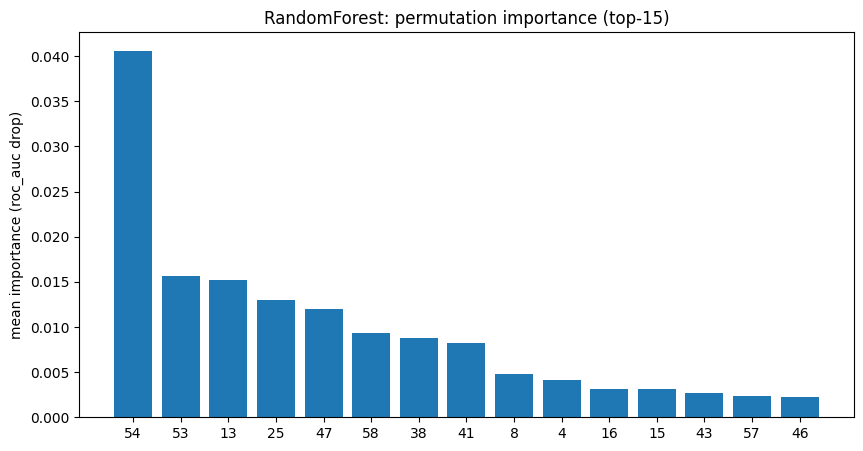

In [53]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(idx)), imp[idx], align='center')
plt.xticks(range(len(idx)), idx)
plt.ylabel(f"mean importance ({scoring} drop)")
plt.title(f"{best_row['label']}: permutation importance (top-15)")
plt.savefig(ARTIFACTS_DIR / f"figures/{best_row['label']}_permutation_importance.png")
plt.show()

In [54]:
"""
    54 и 25 признаки больше всего влияют на модель и на таргет

    Этот вывод не очень понятен на основе изначальных данных
"""

'\n    54 и 25 признаки больше всего влияют на модель и на таргет\n\n    Этот вывод не очень понятен на основе изначальных данных\n'